In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import blimpy as bl 
import glob
import os
%matplotlib inline

In [2]:
dfa = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/seticore_output/findevent/all_events.csv')

In [3]:
df = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/BL_star_targets_all_sky.csv')
df

,Name,RA,DEC,Vmag,Sp.Type,dist (pc),ObsDate,Unnamed: 7
0,HIP2,0 0 1.22,-19 29 55,9.27,K3V,45.6,12/13/2020,NaN
1,HIP171,0 2 11.0,27 4 41,5.80,G3V,12.4,11/13/2020,NaN
2,HIP194,0 2 29.6,8 29 6,5.70,F0V,37.6,08/21/2020,NaN
3,HIP400,0 4 56.7,23 16 10,7.82,G9V,25.6,01/19/2020,NaN
4,HIP428,0 5 12.2,45 47 9,9.95,M2,11.4,12/01/2019,NaN
...,...,...,...,...,...,...,...,...
1176,HIP117795,23 53 20.0,59 56 42,10.40,K8,27.3,07/04/2019,NaN
1177,HIP117946,23 55 26.8,22 11 33,8.77,K0,25.4,08/02/2019,NaN
1178,HIP118162,23 58 6.74,50 26 55,6.72,G5,24.1,07/04/2019,NaN
1179,HIP118212,23 58 44.5,46 43 44,9.57,M0,17.3,07/04/2019,NaN


In [4]:
dfu = df.drop(983) # remove duplicate entry for HIP 97222
dfu

,Name,RA,DEC,Vmag,Sp.Type,dist (pc),ObsDate,Unnamed: 7
0,HIP2,0 0 1.22,-19 29 55,9.27,K3V,45.6,12/13/2020,NaN
1,HIP171,0 2 11.0,27 4 41,5.80,G3V,12.4,11/13/2020,NaN
2,HIP194,0 2 29.6,8 29 6,5.70,F0V,37.6,08/21/2020,NaN
3,HIP400,0 4 56.7,23 16 10,7.82,G9V,25.6,01/19/2020,NaN
4,HIP428,0 5 12.2,45 47 9,9.95,M2,11.4,12/01/2019,NaN
...,...,...,...,...,...,...,...,...
1176,HIP117795,23 53 20.0,59 56 42,10.40,K8,27.3,07/04/2019,NaN
1177,HIP117946,23 55 26.8,22 11 33,8.77,K0,25.4,08/02/2019,NaN
1178,HIP118162,23 58 6.74,50 26 55,6.72,G5,24.1,07/04/2019,NaN
1179,HIP118212,23 58 44.5,46 43 44,9.57,M0,17.3,07/04/2019,NaN


In [5]:
targetvec = dfu['Name'].values
ravec = dfu['RA'].values
decvec = dfu['DEC'].values
dvec = dfu['dist (pc)'].values

In [16]:
print(len(targetvec))
print(len(np.unique(targetvec)))

1180
1180


In [54]:
u, c = np.unique(dfa['Source'].values, return_counts=True)
ra_count_vec = []
dec_count_vec = []
c_count_vec = []
s_count_vec = []
event_count = 0
for i in range(len(u)):
    ui = u[i]
    ci = c[i]
    if not ui in targetvec:
        print(ui, 'not in sample')
        continue
    event_count += ci
    ra_count_vec.append(ravec[np.where(targetvec == ui)[0][0]])
    dec_count_vec.append(decvec[np.where(targetvec == ui)[0]])
    s_count_vec.append(ui)
    c_count_vec.append(ci)
ra_count_vec = np.array(ra_count_vec).reshape(-1)
dec_count_vec = np.array(dec_count_vec).reshape(-1)
s_count_vec = np.array(s_count_vec).reshape(-1)
c_count_vec = np.array(c_count_vec).reshape(-1)
print(event_count, 'events total')

HIP24680 not in sample
HIP43615 not in sample
ROSS128 not in sample
77150 events total


In [66]:
u0 = np.unique(np.transpose([s_count_vec, ra_count_vec, dec_count_vec]).astype('str'), axis=0)
u0, idx, counts = np.unique(np.transpose([ra_count_vec, dec_count_vec]).astype('str'), axis=0, return_inverse=True, return_counts=True)
print(idx)
print(u0[np.where(counts>1)[0]])
print(s_count_vec[np.where(ra_count_vec.astype('str') == '19 50 47.5')[0]])

for i in range(len(np.transpose([s_count_vec, ra_count_vec, dec_count_vec]).astype('str'))):
    print(np.transpose([s_count_vec, ra_count_vec, dec_count_vec]).astype('str')[i])

[  43 1059  566 ...  636  637  621]
[['18 5 27.4 ' '2 29 44 ']
 ['19 50 47.5 ' '8 52 12 ']]
[]
['GJ1002' '0 6 42.9 ' '-7 32 51 ']
['GJ1111' '8 29 48.1 ' '26 46 27 ']
['GJ1245AC' '19 53 54.8 ' '44 24 45 ']
['GJ1245B' '19 53 55.8 ' '44 24 46 ']
['GJ144' '3 32 54.7 ' '-9 27 29 ']
['GJ15A' '0 18 27.1 ' '44 1 29 ']
['GJ15B' '0 18 29.7 ' '44 1 44 ']
['GJ166' '4 15 13.8 ' '-7 40 4 ']
['GJ166BC' '4 15 19.3 ' '-7 40 11 ']
['GJ234' '6 29 24.1 ' '-2 48 59 ']
['GJ244' '6 45 8.29 ' '-16 43 17 ']
['GJ273' '7 27 25.1 ' '5 12 33 ']
['GJ280' '7 39 17.3 ' '5 13 13 ']
['GJ380' '10 11 19.8 ' '49 27 6 ']
['GJ388' '10 19 35.8 ' '19 52 9 ']
['GJ406' '10 56 25.0 ' '7 0 9 ']
['GJ411' '11 3 19.4 ' '35 56 55 ']
['GJ412A' '11 5 22.1 ' '43 31 51 ']
['GJ412B' '11 5 23.8 ' '43 31 32 ']
['GJ447' '11 47 45.0 ' '0 47 56 ']
['GJ473AB' '12 33 15.4 ' '9 1 19 ']
['GJ54.1' '1 12 31.9 ' '-16 59 45 ']
['GJ628' '16 30 17.9 ' '-12 40 3 ']
['GJ65A' '1 39 5.01 ' '-17 56 52 ']
['GJ687' '17 36 24.9 ' '68 20 0 ']
['GJ699' '17 57 47.

In [24]:
import astropy
print(ravec)
a_ravec = np.array([astropy.coordinates.Angle(ra + ' hours').radian for ra in ravec])
a_decvec = np.array([astropy.coordinates.Angle(dec + ' degrees').radian for dec in decvec])
print(a_ravec)
c_ravec = np.array([astropy.coordinates.Angle(ra + ' hours').radian for ra in ra_count_vec])
c_decvec = np.array([astropy.coordinates.Angle(dec + ' degrees').radian for dec in dec_count_vec])

['0 0 1.22 ' '0 2 11.0 ' '0 2 29.6 ' ... '23 58 6.74 ' '23 58 44.5 '
 '23 59 47.7 ']
[8.87209036e-05 9.52658883e-03 1.08792190e-02 ... 6.27494881e+00
 6.27769479e+00 6.28229083e+00]


In [25]:
a_ravec_modified = []
for a in a_ravec:
    if a >= np.pi:
        new_a = a - 2*np.pi
    else:
        new_a = a
    a_ravec_modified.append(new_a)

c_ravec_modified = []
for a in c_ravec:
    if a >= np.pi:
        new_a = a - 2*np.pi
    else:
        new_a = a
    c_ravec_modified.append(new_a)

In [7]:
print(a_decvec.min())
print(-20*np.pi/180)

-0.3486828475907893
-0.3490658503988659


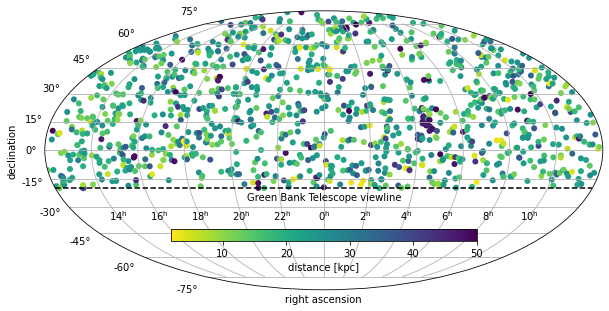

In [8]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection="mollweide")
ax.grid(True)

s = ax.scatter(a_ravec_modified, a_decvec, c=dvec, cmap='viridis_r', lw=0)
plt.axhline(-20*np.pi/180, color='k', ls='--')
ax.text(0, -25*np.pi/180, 'Green Bank Telescope viewline', ha='center', va='center')

cax = ax.inset_axes([-120*np.pi/180, -50*np.pi/180, 240*np.pi/180, 7*np.pi/180], transform=ax.transData)
fig.colorbar(s, cax=cax, orientation='horizontal', label='distance [kpc]')
ax.set_xlabel('right ascension')
ax.set_ylabel('declination')
#help(ax.spines['geo'])
#print(ax.spines['geo'].get_position())
#ax.spines['geo'].set_position(('data', -35*np.pi/180))
#ax.tick_params(axis='x', which='major', pad=50)
ax.set_xticklabels([])
xticklabelvec = [r'14$^\mathrm{h}$', 
                    r'16$^\mathrm{h}$', 
                    r'18$^\mathrm{h}$',
                    r'20$^\mathrm{h}$', 
                    r'22$^\mathrm{h}$', 
                    r'0$^\mathrm{h}$',
                    r'2$^\mathrm{h}$',
                    r'4$^\mathrm{h}$',
                    r'6$^\mathrm{h}$',
                    r'8$^\mathrm{h}$', 
                    r'10$^\mathrm{h}$']
xtickvec = ax.get_xticks()
#print(xtickvec)
for i, x in enumerate(xticklabelvec):
    xpos = xtickvec[i]
    ax.text(xpos, -35*np.pi/180, x, ha='center', va='center')
plt.savefig('/datax/scratch/benjb/bl_nearby_stars/Fig_sky_distribution_of_sources.pdf', bbox_inches='tight')
plt.show()

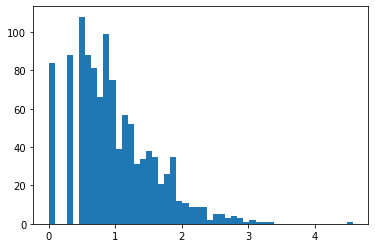

In [29]:
plt.hist(np.log10(c_count_vec), bins=50)
plt.show()

In [ ]:
c_ravec_modified[np.argmax(c_count_vec)]

In [49]:
print(len(np.transpose([np.array(c_ravec_modified).reshape(-1), np.array(c_decvec).reshape(-1)])))
print(len(np.unique(np.transpose([np.array(c_ravec_modified).reshape(-1), np.array(c_decvec).reshape(-1)]), axis=0)))

1136
1133


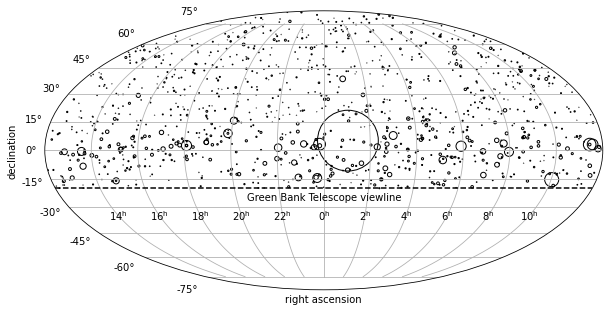

In [62]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection="mollweide")
ax.grid(True)

# s = ax.scatter(c_ravec_modified, c_decvec, s=np.log10(c_count_vec)*10, lw=0, zorder=1)
# s = ax.scatter(c_ravec_modified[np.argmax(c_count_vec)],
#                c_decvec[np.argmax(c_count_vec)],
#                s = 20*np.log10(c_count_vec)[np.argmax(c_count_vec)],
#                lw=0, zorder=0)

s = ax.scatter(c_ravec_modified, c_decvec, s=np.array(c_count_vec)/10, lw=1, facecolors='none', edgecolors='k', zorder=1)
# s = ax.scatter(c_ravec_modified[np.argmax(c_count_vec)],
#                c_decvec[np.argmax(c_count_vec)],
#                s = c_count_vec[np.argmax(c_count_vec)]/50,
#                lw=0, zorder=0)
plt.axhline(-20*np.pi/180, color='k', ls='--')
ax.text(0, -25*np.pi/180, 'Green Bank Telescope viewline', ha='center', va='center')

# cax = ax.inset_axes([-120*np.pi/180, -50*np.pi/180, 240*np.pi/180, 7*np.pi/180], transform=ax.transData)
# fig.colorbar(s, cax=cax, orientation='horizontal', label='distance [kpc]')
ax.set_xlabel('right ascension')
ax.set_ylabel('declination')
#help(ax.spines['geo'])
#print(ax.spines['geo'].get_position())
#ax.spines['geo'].set_position(('data', -35*np.pi/180))
#ax.tick_params(axis='x', which='major', pad=50)
ax.set_xticklabels([])
xticklabelvec = [r'14$^\mathrm{h}$', 
                    r'16$^\mathrm{h}$', 
                    r'18$^\mathrm{h}$',
                    r'20$^\mathrm{h}$', 
                    r'22$^\mathrm{h}$', 
                    r'0$^\mathrm{h}$',
                    r'2$^\mathrm{h}$',
                    r'4$^\mathrm{h}$',
                    r'6$^\mathrm{h}$',
                    r'8$^\mathrm{h}$', 
                    r'10$^\mathrm{h}$']
xtickvec = ax.get_xticks()
#print(xtickvec)
for i, x in enumerate(xticklabelvec):
    xpos = xtickvec[i]
    ax.text(xpos, -35*np.pi/180, x, ha='center', va='center')
plt.savefig('/datax/scratch/benjb/bl_nearby_stars/Fig_sky_distribution_of_events_linear.pdf', bbox_inches='tight')
plt.show()

In [9]:
print(dvec.max())

50.0
